In [1]:
!git clone https://github.com/yell/boltzmann-machines.git
import numpy as np
import tensorflow as tf
tf.logging.set_verbosity(tf.logging.ERROR)
import matplotlib.pyplot as plt
from JSAnimation.IPython_display import display_animation
from sklearn.metrics import accuracy_score, confusion_matrix

import env
from boltzmann_machines.dbm import DBM
from boltzmann_machines.rbm import GaussianRBM, MultinomialRBM
from boltzmann_machines.utils import (progress_bar, RNG, 
                                      im_plot, im_reshape, im_gif, tick_params, plot_confusion_matrix)
from boltzmann_machines.utils.augmentation import shift, horizontal_mirror
from boltzmann_machines.utils.dataset import (load_cifar10, plot_cifar10, get_cifar10_labels,
                                              im_unflatten, im_rescale)

%matplotlib inline
%load_ext autoreload
%autoreload 2

## load CIFAR-10

In [2]:
X, y = load_cifar10(mode='train', path='../data/')
print X.shape, y.shape

(50000, 3072) (50000,)


In [ ]:
plt.figure(figsize=(10, 10))
plot_cifar10(im_unflatten(X[:1000]), y[:1000], samples_per_class=10)
plt.savefig('cifar10.png', dpi=196, bbox_inches='tight')

## load augmented CIFAR-10

In [4]:
X_aug = np.load('../data/X_aug.npy')
print X_aug.shape, X_aug.dtype

(490000, 3072) uint8


### sanity check: each row should contain an original image from CIFAR-10 (1), image shifted by 1 pixel in all directions (4), and also mirrored versions of such images (5)

In [ ]:
n_train = len(X_aug) / 10
ind = range(10 * n_train)
RNG(seed=1337).shuffle(ind)
imgs_id = [1, 2, 3, 20, 21, 22, 23, 50, 60, 70]
shuffled_ind = []
for i in imgs_id:
    for k in xrange(10):
        shuffled_ind.append(ind.index(k * n_train + i))
Y = X_aug[shuffled_ind, ...]
Y = im_unflatten(Y)
fig = plt.figure(figsize=(10, len(imgs_id)))
im_plot(Y, n_width=10, n_height=len(imgs_id), title='Augmented CIFAR-10', 
        title_params={'fontsize': 22});
plt.savefig('cifar10_aug.png', dpi=196, bbox_inches='tight')

## load small RBMs trained on 8x8 patches of images and visualize filters

In [6]:
def plot_small_rbm_W(prefix='dbm_cifar2_rbm_small_', rbm_id=0):
    assert 0 <= rbm_id <= 25
    
    # load RBM weights
    rbm_small = GaussianRBM.load_model('../models/rbm_cifar_small_{0}/'.format(rbm_id))
    rbm_small_W = rbm_small.get_tf_params(scope='weights')['W']
    print rbm_small_W.shape

    # prepare for plotting
    W = im_rescale( rbm_small_W.T )

    # plot
    fig = plt.figure(figsize=(8, 8))
    im_plot(W, title='First 100 filters extracted by small RBM #{0}/26'.format(rbm_id + 1), 
            title_params={'fontsize': 18})
    plt.savefig('{0}{1}.png'.format(prefix, rbm_id), dpi=196, bbox_inches='tight');

In [ ]:
# trained on top-left parts of images:
# +---+---+---+---+
# | x |   |   |   |
# +---+---+---+---+
# |   |   |   |   |
# +---+---+---+---+
# |   |   |   |   |
# +---+---+---+---+
# |   |   |   |   |
# +---+---+---+---+
plot_small_rbm_W(rbm_id=0)

In [ ]:
# trained on these parts of images:
# +---+---+---+---+
# |   |   | x |   |
# +---+---+---+---+
# |   |   |   |   |
# +---+---+---+---+
# |   |   |   |   |
# +---+---+---+---+
# |   |   |   |   |
# +---+---+---+---+
plot_small_rbm_W(rbm_id=2)

In [ ]:
# trained on these parts of images:
# +---+---+---+---+
# |   |   |   |   |
# +---+---+---+---+
# |   |   |   |   |
# +---+---+---+---+
# |   |   | x |   |
# +---+---+---+---+
# |   |   |   |   |
# +---+---+---+---+
plot_small_rbm_W(rbm_id=10)

In [ ]:
# trained on precise centers of images:
# +---+---+---+---+
# | +---+---+---+ |
# | |   |   |   | |
# | +---+---+---+ |
# | |   | x |   | |
# | +---+---+---+ |
# | |   |   |   | |
# | +---+---+---+ |
# +---+---+---+---+
plot_small_rbm_W(rbm_id=20)

## load pre-trained Gaussian RBM

In [ ]:
# load RBM weights
grbm = GaussianRBM.load_model('../models/grbm_cifar2/')
grbm_W = grbm.get_tf_params(scope='weights')['W']
print grbm_W.shape

# prepare for plotting
W = im_rescale( grbm_W.copy().T )

# plot
ind = RNG(seed=1337).choice(range(7800), size=100).tolist()
fig = plt.figure(figsize=(10, 10))
im_plot(W[ind, ...], title='Random 100 filters extracted by Gaussian RBM')
plt.savefig('dbm_cifar2_grbm.png', dpi=196, bbox_inches='tight');

## load pre-trained Multinomial RBM

In [ ]:
# load RBM weights
mrbm = MultinomialRBM.load_model('../models/mrbm_cifar2/')
mrbm_W = mrbm.get_tf_params(scope='weights')['W']
print mrbm_W.shape

# prepare for plotting
W = grbm_W.dot(mrbm_W)
W = im_rescale( W.T )

# plot
fig = plt.figure(figsize=(10, 10))
im_plot(W, title='First 100 filters extracted by Multinomial RBM')
plt.savefig('dbm_cifar2_mrbm.png', dpi=196, bbox_inches='tight');

## load trained DBM and visualize filters in layers 1 and 2

In [13]:
dbm = DBM.load_model('../models/dbm_cifar2/')
dbm.load_rbms([grbm, mrbm])  # !!!

In [14]:
weights = dbm.get_tf_params('weights')
W1 = weights['W']
W2 = weights['W_1']
print W1.shape, W2.shape

(3072, 7800) (7800, 512)


In [ ]:
# prepare for plotting
W = im_rescale( W1.copy().T )

# plot
fig = plt.figure(figsize=(10, 10))
ind = RNG(seed=1337).choice(range(7800), size=100).tolist()
im_plot(W[ind, ...], title='Random 100 filters of DBM after joint training (1st layer)',
       title_params={'fontsize': 19})
plt.savefig('dbm_cifar2_W1_joint.png', dpi=196, bbox_inches='tight');

In [ ]:
# prepare for plotting
W = W1.dot(W2)
W = im_rescale( W.T )

# plot
fig = plt.figure(figsize=(10, 10))
im_plot(W, title='First 100 filters of DBM after joint training (2nd layer)', 
        title_params={'fontsize': 20})
plt.savefig('dbm_cifar2_W2_joint.png', dpi=196, bbox_inches='tight');

# generate samples after training

In [17]:
X_aug_mean = np.load('../data/X_aug_mean.npy')
X_aug_std = np.load('../data/X_aug_std.npy')

In [18]:
V = dbm.sample_v(n_gibbs_steps=0)
print V.shape

(100, 3072)


In [ ]:
# prepare for plotting
V = im_rescale(V, mean=X_aug_mean, std=X_aug_std)

# plot
fig = plt.figure(figsize=(10, 10))
im_plot(V, title='Samples generated by DBM after training');
plt.savefig('dbm_cifar2_samples.png', dpi=196, bbox_inches='tight');

## generate more samples
**(note that new samples override previous particles on disk)**

In [20]:
V = im_reshape(V, n_width=10, n_height=10)
samples = [V]
for i in progress_bar(range(100)):
    V = dbm.sample_v(n_gibbs_steps=50, save_model=True)
    V = im_rescale(V, mean=X_aug_mean, std=X_aug_std)
    V = im_reshape(V, n_width=10, n_height=10)
    samples.append(V)

A Jupyter Widget

## make an animation and save to disk

In [ ]:
fig = plt.figure(figsize=(6, 6), tight_layout=True)
im = plt.imshow(np.zeros((320, 320, 3), dtype='uint8'), animated=True, vmin=0, vmax=255)
im.axes.tick_params(**tick_params())

anim = im_gif(samples, im, fig, fname='dbm_cifar2_samples.gif',
              title_func=lambda i: 'Samples generated by DBM after {0} Gibbs steps'.format(50 * i),
              title_params={'fontsize': 15, 'y': 1.02}, anim_params={'interval': 300}, save_params={'dpi': 144})

display_animation(anim)

# Gaussian RBM discriminative fine-tuning
## load predictions, targets, and fine-tuned weights

In [22]:
y_pred = np.load('../data/grbm_y_pred.npy')
y_test = np.load('../data/grbm_y_test.npy')
W_finetuned = np.load('../data/grbm_W_finetuned.npy')
print accuracy_score(y_test, y_pred)

0.6811


## plot confusion matrix
Notice how infrequently animal is mistaken for a non-animal (or vice versa) and how frequently animal is mistaken to another animal (and the same for non-animal). The matrix therefore has block structure.

In [ ]:
C = confusion_matrix(y_test, y_pred)

fig = plt.figure(figsize=(10, 8))
ax = plot_confusion_matrix(C, labels=get_cifar10_labels(), labels_fontsize=12, fmt='d')
plt.title('Confusion matrix for fine-tuned G-RBM\n', fontsize=20, y=0.97)
plt.savefig('dbm_cifar_grbm_confusion_matrix.png', dpi=144, bbox_inches='tight')

## visualize filters after fine-tuning

In [ ]:
# prepare for plotting
W = im_rescale( W_finetuned.T )

# plot
fig = plt.figure(figsize=(10, 10))
ind = RNG(seed=1337).choice(range(7800), size=100).tolist()
im_plot(W[ind, ...], title='Random 100 filters of Gaussian RBM after fine-tuning',
       title_params={'fontsize': 19})
plt.savefig('dbm_cifar_grbm_finetuned.png', dpi=196, bbox_inches='tight');

## discriminative fine-tuning w/o data augmentation

In [25]:
y_pred = np.load('../data/grbm_no_aug_y_pred.npy')
y_test = np.load('../data/grbm_no_aug_y_test.npy')
W_finetuned = np.load('../data/grbm_no_aug_W_finetuned.npy')
print accuracy_score(y_test, y_pred)

0.6438


In [ ]:
C = confusion_matrix(y_test, y_pred)

fig = plt.figure(figsize=(10, 8))
ax = plot_confusion_matrix(C, labels=get_cifar10_labels(), labels_fontsize=12, fmt='d')
plt.title('Confusion matrix for fine-tuned G-RBM\n', fontsize=20, y=0.97)
plt.savefig('dbm_cifar_grbm_no_aug_confusion_matrix.png', dpi=144, bbox_inches='tight')

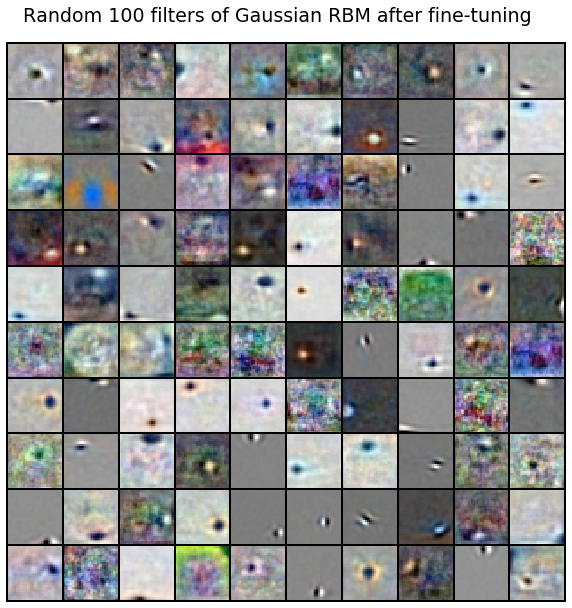

In [27]:
# prepare for plotting
W = im_rescale( W_finetuned.T )

# plot
fig = plt.figure(figsize=(10, 10))
ind = RNG(seed=1337).choice(range(7800), size=100).tolist()
im_plot(W[ind, ...], title='Random 100 filters of Gaussian RBM after fine-tuning',
       title_params={'fontsize': 19})
plt.savefig('dbm_cifar_grbm_no_aug_finetuned.png', dpi=196, bbox_inches='tight');